# Basic Walk-Through (Python API)

This notebook fits a bespoke force field via the Python API. It mirrors the CLI walk-through but builds `WorkflowSettings` programmatically. Use the Python API when you want to:

- Sweep settings or batch-fit many molecules.
- Inject runtime objects (e.g. an [ASE calculator](../how-to/use-ase-calculator.md)) that can't round-trip through YAML.
- Integrate `presto` into a larger pipeline.

For the CLI version of the same fit, see [`basic-walk-through-cli.ipynb`](basic-walk-through-cli.ipynb).

## 1. Build a `WorkflowSettings`

In [1]:
from presto.settings import ParameterisationSettings, WorkflowSettings
from presto.workflow import get_bespoke_force_field

settings = WorkflowSettings(
    parameterisation_settings=ParameterisationSettings(
        molecule_input_type="smiles",
        molecules="CCO",
    ),
    device_type="cuda",
    n_iterations=2,
)
settings

WorkflowSettings(version='0.7.1.dev16+gb27d5656f.d20260527', output_dir=PosixPath('.'), device_type='cuda', n_iterations=2, memory=False, parameterisation_settings=ParameterisationSettings(molecule_input_type='smiles', molecules=['CCO'], initial_force_field='openff_unconstrained-2.3.0.offxml', expand_torsions=True, linearise_harmonics=True, msm_settings=MSMSettings(mlp_settings=MLPSettings(ml_potential='aimnet2', ml_potential_kwargs={}, ml_system_kwargs={}), finite_step=0.0005291772 nm, tolerance=0.005291772 kcal/(A mol), vib_scaling=1.0, n_conformers=1), type_generation_settings={'Bonds': TypeGenerationSettings(max_extend_distance=-1, include=[], exclude=[]), 'Angles': TypeGenerationSettings(max_extend_distance=-1, include=[], exclude=[]), 'ProperTorsions': TypeGenerationSettings(max_extend_distance=-1, include=[], exclude=['[*:1]-[*:2]#[*:3]-[*:4]', '[*:1]~[*:2]-[*:3]#[*:4]', '[*:1]~[*:2]=[#6,#7,#16,#15;X2:3]=[*:4]']), 'ImproperTorsions': TypeGenerationSettings(max_extend_distance=-1

Validation runs at construction time — invalid configurations raise `InvalidSettingsError` immediately. See the [API reference](../reference/api/settings.md) for the full settings documentation.

## 2. Round-trip via YAML

`WorkflowSettings.to_yaml` writes a settings file you can later replay with `presto train-from-yaml`.

In [2]:
settings.to_yaml("workflow_settings.yaml")

# Reload, with a one-off override
from presto.settings import WorkflowSettings

reloaded = WorkflowSettings.from_yaml(
    "workflow_settings.yaml",
    overwrite={"training_settings": {"n_epochs": 200}},
)
reloaded.training_settings.n_epochs

200

## 3. Run the fit

`get_bespoke_force_field` returns the final fitted `openff.toolkit.ForceField` and writes the same outputs `presto train` would (see [Output directory layout](../concepts/output-layout.md)).

In [ ]:
bespoke_ff = get_bespoke_force_field(settings)
bespoke_ff

## 4. Use the bespoke force field

The returned object is a standard SMIRNOFF `ForceField`. Use it like any other OpenFF force field:

In [4]:
from openff.toolkit import Molecule

mol = Molecule.from_smiles("CCO")
system = bespoke_ff.create_interchange(mol.to_topology()).to_openmm()
system

INFO:openff.interchange.smirnoff._nonbonded:Charge section NAGLCharges, using NAGL model 
openff-gnn-am1bcc-1.0.0.pt, applied to topology atom index 0

INFO:openff.interchange.smirnoff._nonbonded:Charge section NAGLCharges, using NAGL model 
openff-gnn-am1bcc-1.0.0.pt, applied to topology atom index 1

INFO:openff.interchange.smirnoff._nonbonded:Charge section NAGLCharges, using NAGL model 
openff-gnn-am1bcc-1.0.0.pt, applied to topology atom index 2

INFO:openff.interchange.smirnoff._nonbonded:Charge section NAGLCharges, using NAGL model 
openff-gnn-am1bcc-1.0.0.pt, applied to topology atom index 3

INFO:openff.interchange.smirnoff._nonbonded:Charge section NAGLCharges, using NAGL model 
openff-gnn-am1bcc-1.0.0.pt, applied to topology atom index 4

INFO:openff.interchange.smirnoff._nonbonded:Charge section NAGLCharges, using NAGL model 
openff-gnn-am1bcc-1.0.0.pt, applied to topology atom index 5

INFO:openff.interchange.smirnoff._nonbonded:Charge section NAGLCharges, using NAGL model 
openff-gnn-am1bcc-1.0.0.pt, applied to topology atom index 6

INFO:openff.interchange.smirnoff._nonbonded:Charge section NAGLCharges, using NAGL model 
openff-gnn-am1bcc-1.0.0.pt, applied to topology atom index 7

INFO:openff.interchange.smirnoff._nonbonded:Charge section NAGLCharges, using NAGL model 
openff-gnn-am1bcc-1.0.0.pt, applied to topology atom index 8

<openmm.openmm.System; proxy of <Swig Object of type 'OpenMM::System *' at 0x77c9efe56d30> >

## 5. Inspect outputs

The plots and diagnostic files live under `<output_dir>/plots/`. For what each plot means, see [Inspect outputs and plots](../how-to/inspect-outputs.md).

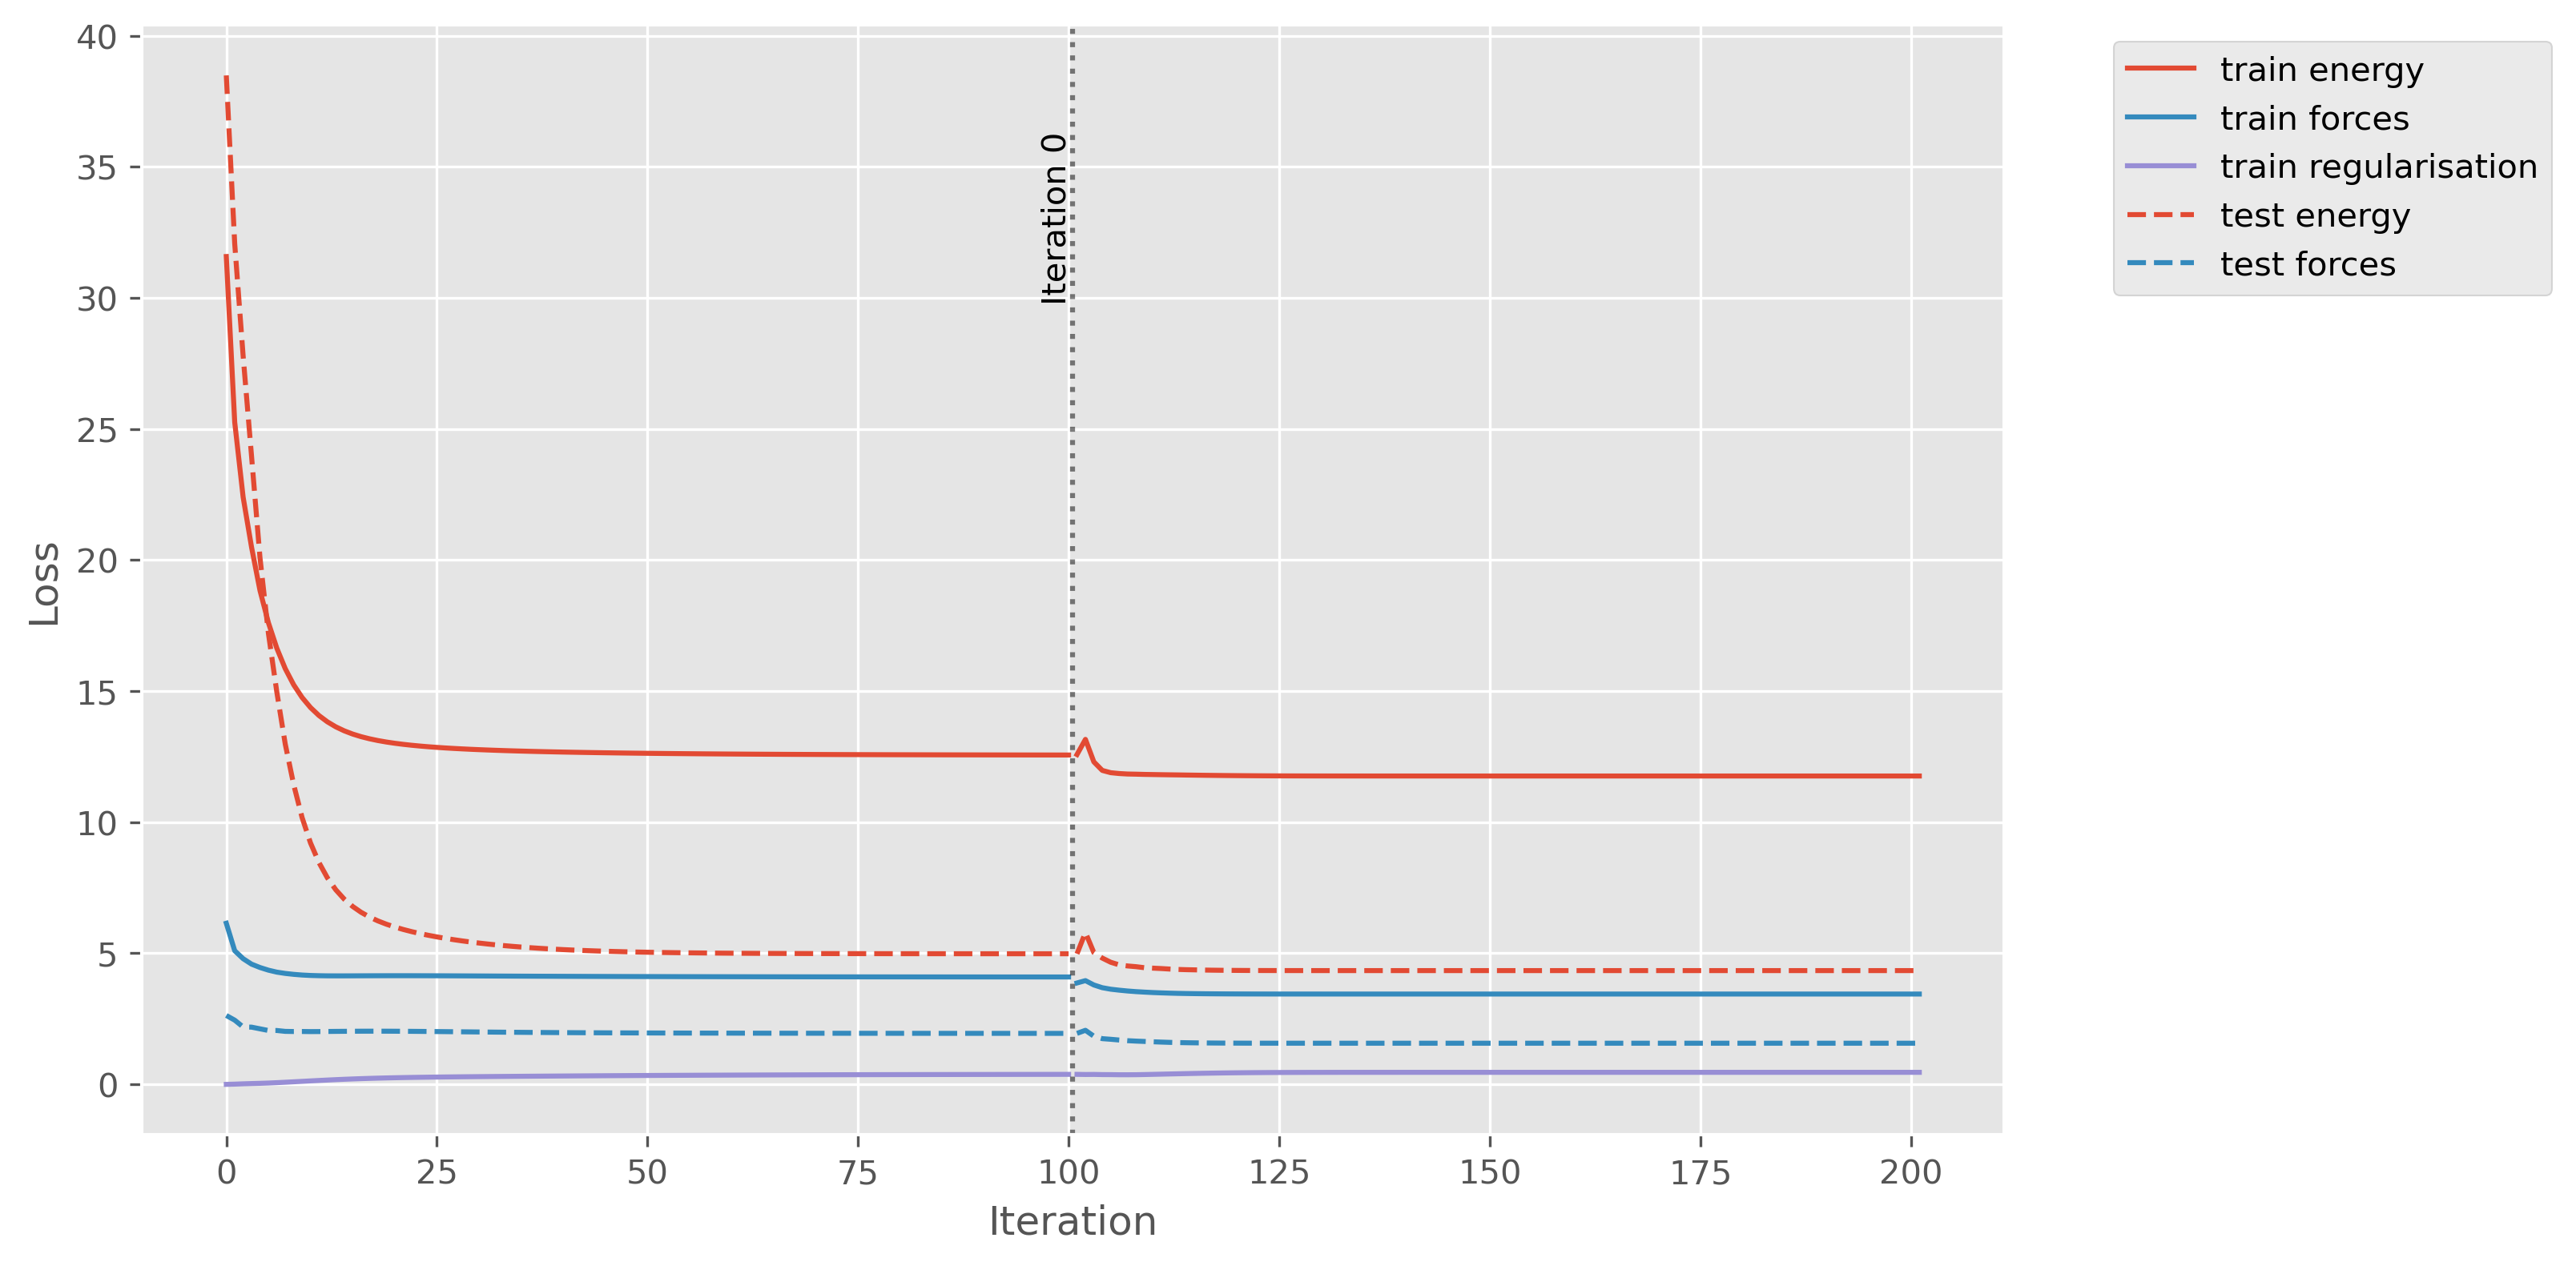

In [5]:
from IPython.display import Image

Image("plots/loss.png")

## 6. Bring your own MLP via ASE

If your reference MLP isn't directly supported by OpenMM-ML, wrap it in an ASE calculator and pass it through `MLPSettings(ml_potential="ase", ml_system_kwargs={"calculator": calc})`. The example below uses ASE's built-in `EMT` calculator for portability — replace it with your real MLP. See [Use an ASE calculator](../how-to/use-ase-calculator.md) for the full pattern.

In [6]:
from ase.calculators.emt import EMT

from presto.settings import (
    MLMDSamplingSettings,
    MLPSettings,
    MSMSettings,
    ParameterisationSettings,
    WorkflowSettings,
)

ase_calculator = EMT()  # replace with your real MLP

# The MLP is used in three places — MSM, training sampling, and testing
# sampling — so all three must be updated.
ase_mlp = MLPSettings(
    ml_potential="ase",
    ml_system_kwargs={
        "calculator": ase_calculator,
        # Charge must be passed explicitly for ASE-backed MLPs.
        "info": {"charge": 0},
    },
)

ase_settings = WorkflowSettings(
    parameterisation_settings=ParameterisationSettings(
        molecule_input_type="smiles",
        molecules="CCO",
        msm_settings=MSMSettings(mlp_settings=ase_mlp),
    ),
    device_type="cuda",
    training_sampling_settings=MLMDSamplingSettings(mlp_settings=ase_mlp),
    testing_sampling_settings=MLMDSamplingSettings(mlp_settings=ase_mlp),
)

## 7. Reload an ASE settings YAML

Runtime objects (the ASE calculator) cannot round-trip through YAML, so `to_yaml` replaces them with a placeholder. Reload with `from_yaml(..., overwrite=...)` to inject the live calculator before validation:

In [7]:
ase_settings.to_yaml("ase_workflow_settings.yaml")

ase_kwargs = {"ml_system_kwargs": {"calculator": ase_calculator}}

loaded = WorkflowSettings.from_yaml(
    "ase_workflow_settings.yaml",
    overwrite={
        "parameterisation_settings": {
            "msm_settings": {"mlp_settings": ase_kwargs}
        },
        "training_sampling_settings": {"mlp_settings": ase_kwargs},
        "testing_sampling_settings": {"mlp_settings": ase_kwargs},
    },
)

## Next steps

- [How-to → Run from Python](../how-to/run-from-python.md) — the prose reference for the patterns shown here.
- [How-to → Fit a congeneric series](../how-to/fit-congeneric-series.md) — share parameters across related molecules.
- [Concepts → MLPs in presto](../concepts/mlps.md) — pick the right reference MLP.